In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pytz
import datetime

In [2]:
df = pd.read_csv("../data/EDA_Gold_Silver_prices.csv")

In [3]:
df.dtypes

Month           object
SilverPrice    float64
GoldPrice      float64
dtype: object

In [4]:
# pd.DatetimeIndex(df['Month'])

In [5]:
datetime.datetime.strptime(df["Month"][0], "%b-%y")

datetime.datetime(1997, 3, 1, 0, 0)

In [6]:
[str(x) + " " for x in pytz.all_timezones]

['Africa/Abidjan ',
 'Africa/Accra ',
 'Africa/Addis_Ababa ',
 'Africa/Algiers ',
 'Africa/Asmara ',
 'Africa/Asmera ',
 'Africa/Bamako ',
 'Africa/Bangui ',
 'Africa/Banjul ',
 'Africa/Bissau ',
 'Africa/Blantyre ',
 'Africa/Brazzaville ',
 'Africa/Bujumbura ',
 'Africa/Cairo ',
 'Africa/Casablanca ',
 'Africa/Ceuta ',
 'Africa/Conakry ',
 'Africa/Dakar ',
 'Africa/Dar_es_Salaam ',
 'Africa/Djibouti ',
 'Africa/Douala ',
 'Africa/El_Aaiun ',
 'Africa/Freetown ',
 'Africa/Gaborone ',
 'Africa/Harare ',
 'Africa/Johannesburg ',
 'Africa/Juba ',
 'Africa/Kampala ',
 'Africa/Khartoum ',
 'Africa/Kigali ',
 'Africa/Kinshasa ',
 'Africa/Lagos ',
 'Africa/Libreville ',
 'Africa/Lome ',
 'Africa/Luanda ',
 'Africa/Lubumbashi ',
 'Africa/Lusaka ',
 'Africa/Malabo ',
 'Africa/Maputo ',
 'Africa/Maseru ',
 'Africa/Mbabane ',
 'Africa/Mogadishu ',
 'Africa/Monrovia ',
 'Africa/Nairobi ',
 'Africa/Ndjamena ',
 'Africa/Niamey ',
 'Africa/Nouakchott ',
 'Africa/Ouagadougou ',
 'Africa/Porto-Novo ',


In [7]:
df["Month"]

0      Mar-97
1      Apr-97
2      May-97
3      Jun-97
4      Jul-97
        ...  
236    Nov-16
237    Dec-16
238    Jan-17
239    Feb-17
240    Mar-17
Name: Month, Length: 241, dtype: object

In [8]:
from datetime import datetime

In [9]:
df["Month"][0].split("-")[0] = "03"

In [10]:
from datetime import date

print(date.fromisoformat("2019-12-04"))

print(date.fromisoformat("20191204"))

print(date.fromisoformat("2021-W01-1"))

2019-12-04
2019-12-04
2021-01-04


In [11]:
df.head()

,Month,SilverPrice,GoldPrice
0,Mar-97,186.48,12619.24
1,Apr-97,170.65,12338.59
2,May-97,170.44,12314.94
3,Jun-97,169.96,12202.78
4,Jul-97,155.80,11582.07


In [12]:
d = date.fromordinal(730920)

In [13]:
d.strftime("%M-%y")

'00-02'

In [14]:
print(df.corr(numeric_only=True))

             SilverPrice  GoldPrice
SilverPrice     1.000000   0.954256
GoldPrice       0.954256   1.000000


In [15]:
np.cov(df["SilverPrice"], df["GoldPrice"])

array([[2.48540951e+05, 1.37653999e+07],
       [1.37653999e+07, 8.37239964e+08]])

In [16]:
print(df["SilverPrice"].corr(df["GoldPrice"]).__round__(2))

0.95


In [17]:
df1 = pd.read_csv("../data/1.csv")

In [18]:
df1["SilverPrice"].corr(df1["GoldPrice"]).__round__(2)

np.float64(0.01)

In [19]:
df1.corr(numeric_only=True)

,SilverPrice,GoldPrice
SilverPrice,1.000000,0.009584
GoldPrice,0.009584,1.000000


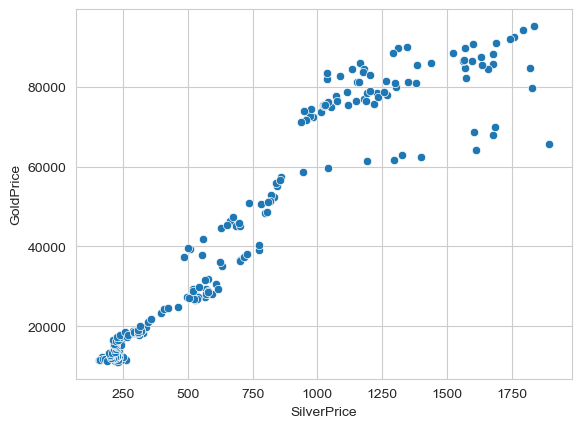

In [23]:
names = ["Silver", "Gold"]
sns.scatterplot(df, x="SilverPrice", y="GoldPrice", hue_order=names)
plt.show()

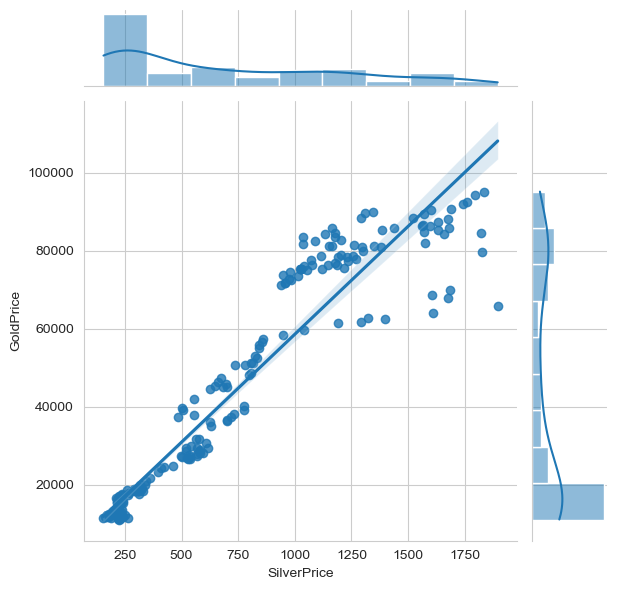

In [21]:
sns.jointplot(df, x="SilverPrice", y="GoldPrice", kind="reg")
plt.show()

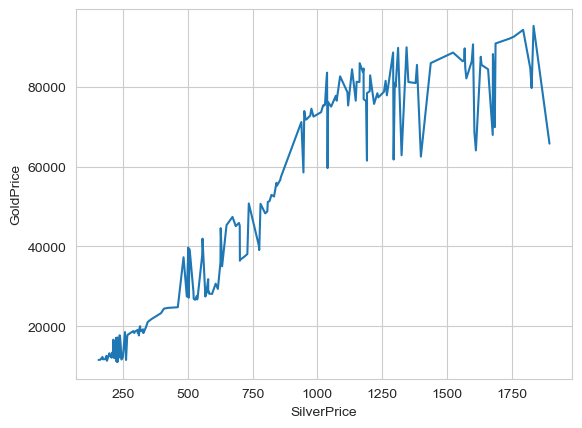

In [50]:
sns.lineplot(df, x="SilverPrice", y="GoldPrice")
plt.show()

In [79]:
from scipy.stats import pearsonr

In [80]:
# Pearson Correlation Coefficient
corr, _ = pearsonr(df["SilverPrice"], df["GoldPrice"])
print(corr)

0.9542559570539784


In [83]:
from scipy.stats import spearmanr

spearman_corr, _ = spearmanr(df["SilverPrice"], df["GoldPrice"])
spearman_corr

0.9480903210154504

### Pearson Correlation Coefficient: .95
### Spearman Correlation: .9482

In [84]:
df.corr(method="kendall", numeric_only=True)

,SilverPrice,GoldPrice
SilverPrice,1.000000,0.817317
GoldPrice,0.817317,1.000000


<Axes: >

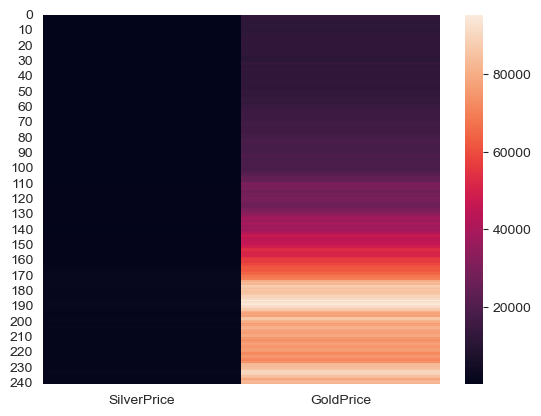

In [25]:
sns.heatmap(df[["SilverPrice", "GoldPrice"]])